In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_validated_data
from src.edit_plot import add_bar_value
from sklearn.preprocessing import RobustScaler
from datetime import datetime

In [94]:
# Load the validated data
data = get_validated_data()
data.head(5)

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues


## General analysis
Find problems that need to be fixed before train models

In [95]:
# General information
print(f'\n---Description--- \n{data[['release_date', 'price', 'recommendations']].describe()}')


---Description--- 
                     release_date         price  recommendations
count                       63995  63995.000000     63995.000000
mean   2023-12-10 12:10:47.375576      7.362776       369.666818
min           2021-01-01 00:00:00      0.000000         0.000000
25%           2022-10-25 00:00:00      0.990000         0.000000
50%           2024-03-07 00:00:00      4.990000         0.000000
75%           2025-03-04 00:00:00      9.990000         0.000000
max           2025-12-31 00:00:00   1900.000000    862487.000000
std                           NaN     17.078056      7018.511212


In [170]:
# Release date analysis
release_years_count = data["release_year"].value_counts()
release_dates = data["release_date"].value_counts()
mean, mode, median, max_date, min_date = (
    release_dates.mean(),
    release_dates.mode()[0],
    release_dates.median(),
    release_dates.max(),
    release_dates.min(),
)
popular_release_dates = release_dates[release_dates > mean].count()
releases_per_month = data["release_date"].dt.month.value_counts()
releases_per_year_month = data.groupby(['release_year', data['release_date'].dt.month]).size().reset_index(name='count')
stats_report = f"""
Release Date Analysis
================================================
Count of days with releases:     {release_dates.count()}
Count of days with above-average releases: {popular_release_dates}

Release Date Statistics
=================================================
Mean:    {mean:.0f}
Mode:     {mode}
Median:  {median:.0f}
Max:   {max_date}
Min:   {min_date}
"""
print(stats_report)


Release Date Analysis
Count of days with releases:     1825
Count of days with above-average releases: 781

Release Date Statistics
Mean:    35
Mode:     17
Median:  31
Max:   150
Min:   1




Release Date Analysis
Count of days with releases:     1825
Count of days with above-average releases: 781

Release Date Statistics
Mean:    35
Mode:     17
Median:  31
Max:   150
Min:   1



C:\Users\Alber\AppData\Local\Temp\ipykernel_12716\300310748.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  years_plot = sns.barplot(x=release_years_count.index, y=release_years_count.values, ax=axes[0, 0], palette='Dark2')
C:\Users\Alber\AppData\Local\Temp\ipykernel_12716\300310748.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  months_plot = sns.barplot(x = releases_per_month.index, y = releases_per_month.values, ax=axes[0, 1], palette='dark')
C:\Users\Alber\AppData\Local\Temp\ipykernel_12716\300310748.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Ju

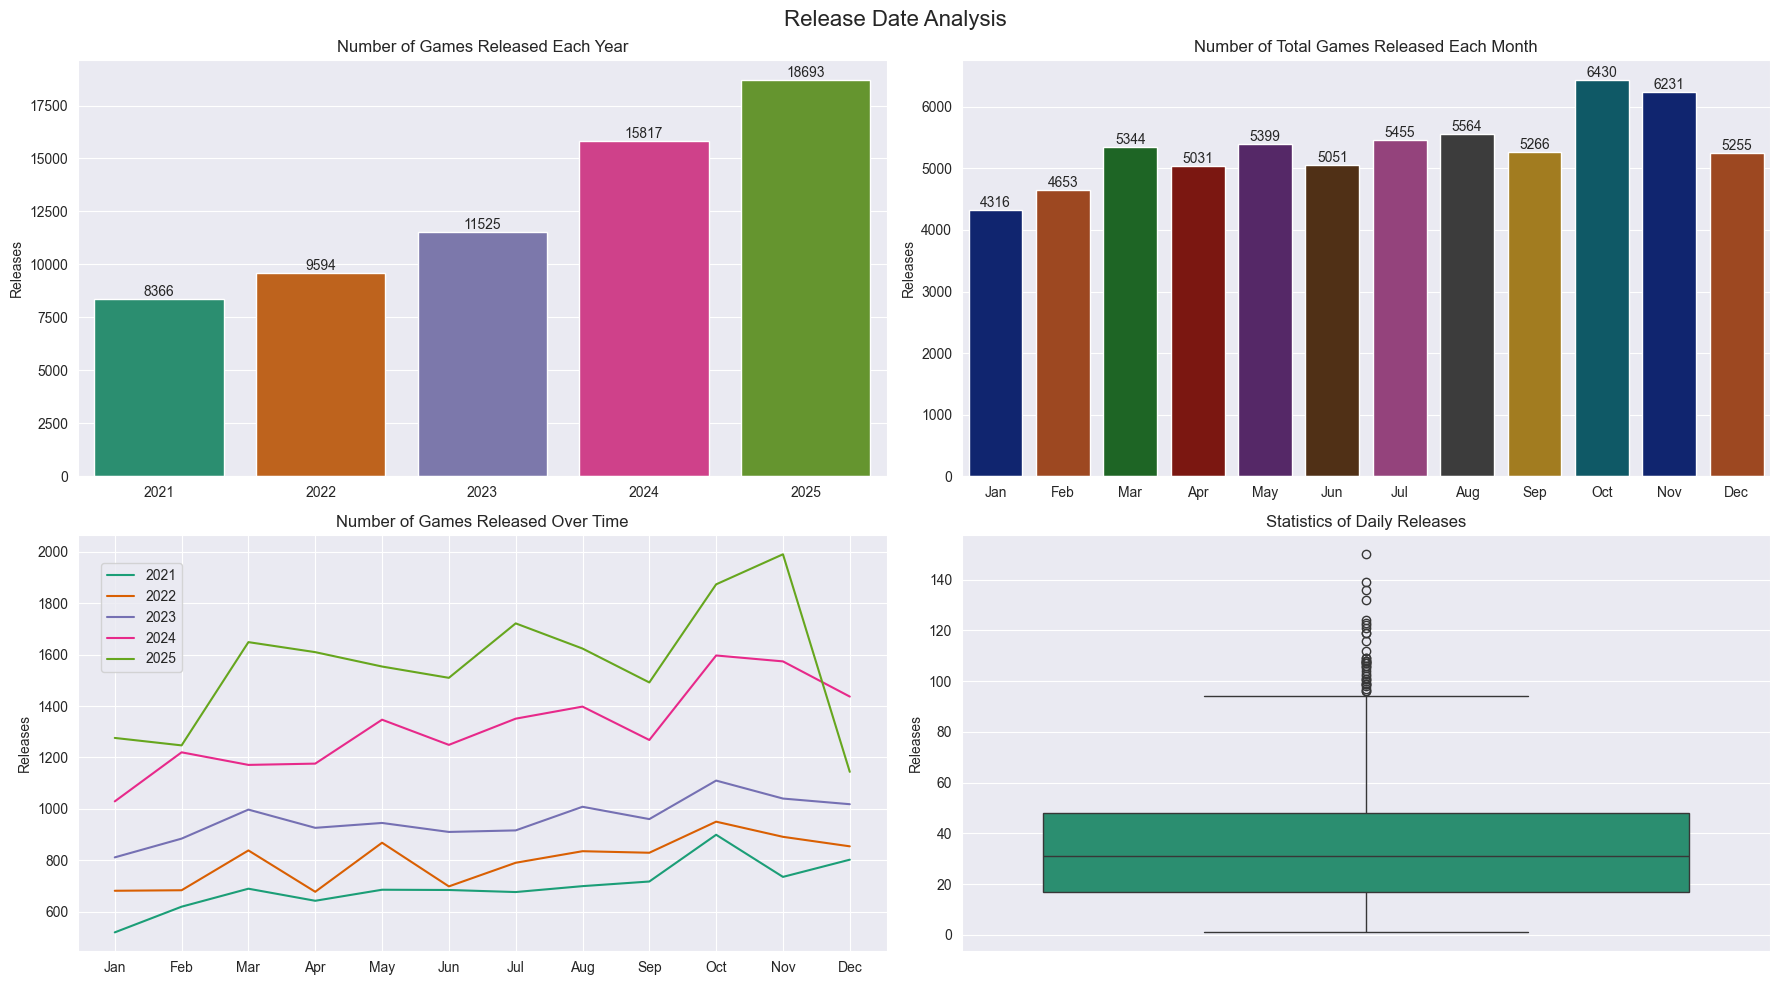

In [ ]:
# Release date analysis
release_years_count = data["release_year"].value_counts()
release_dates = data["release_date"].value_counts()
mean, mode, median, max_date, min_date = (
    release_dates.mean(),
    release_dates.mode()[0],
    release_dates.median(),
    release_dates.max(),
    release_dates.min(),
)
popular_release_dates = release_dates[release_dates > mean].count()
releases_per_month = data["release_date"].dt.month.value_counts()
releases_per_year_month = data.groupby(['release_year', data['release_date'].dt.month]).size().reset_index(name='count')
stats_report = f"""
Release Date Analysis
================================================
Count of days with releases:     {release_dates.count()}
Count of days with above-average releases: {popular_release_dates}
Mean:    {mean:.0f}
Mode:     {mode}
Median:  {median:.0f}
Max:   {max_date}
Min:   {min_date}
"""
print(stats_report)

# Visual Release date analysis
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Release Date Analysis', fontsize=16)

years_plot = sns.barplot(x=release_years_count.index, y=release_years_count.values, ax=axes[0, 0], palette='Dark2')
axes[0,0].set_title('Number of Games Released Each Year')
axes[0,0].set(xlabel=None, ylabel='Releases')
add_bar_value(years_plot)

months_plot = sns.barplot(x = releases_per_month.index, y = releases_per_month.values, ax=axes[0, 1], palette='dark')
axes[0,1].set_title('Number of Total Games Released Each Month')
axes[0,1].set(xlabel=None, ylabel='Releases')
axes[0,1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
add_bar_value(months_plot)

sns.lineplot(data = releases_per_year_month, x = 'release_date', y = 'count', hue='release_year', ax=axes[1, 0], palette='Dark2')
axes[1,0].set_title('Number of Games Released Over Time')
axes[1,0].set(xlabel=None, ylabel='Releases')
axes[1, 0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1,0].legend(bbox_to_anchor=(0.02, 0.95), loc='upper left')
plt.tight_layout()

sns.boxplot(release_dates.values, ax=axes[1, 1], palette='Dark2')
axes[1,1].set(xlabel=None, ylabel='Releases')
axes[1,1].set_title('Statistics of Daily Releases')

plt.show()

In [98]:
# Popular genres combination
splitted_genres = data['genres'].str.split(';')
popular_genres_combination = splitted_genres.value_counts()
genres_count = splitted_genres.explode().value_counts()
number_of_less_popular_genres_combination = len(popular_genres_combination) - 20
print(f'Popular genres combination: {popular_genres_combination.head(15)}')
print(f'\nGenres count: {genres_count.head(20)}')
print(f'\nNumber of less popular genres combination: {number_of_less_popular_genres_combination}')

Popular genres combination: genres
[Casual, Indie]                       4079
[Action, Adventure, Indie]            2801
[Action, Indie]                       2563
[Adventure, Indie]                    2258
[Casual]                              2166
[Adventure, Casual, Indie]            2021
[Action, Casual, Indie]               1676
[Indie]                               1638
[Action]                              1589
[Casual, Indie, Simulation]           1416
[Casual, Indie, Strategy]             1388
[Adventure]                           1216
[Action, Adventure, Casual, Indie]    1131
[Action, Adventure]                    962
[Action, Adventure, Indie, RPG]        781
Name: count, dtype: int64

Genres count: genres
Indie                    45021
Casual                   30150
Adventure                25929
Action                   25123
Simulation               14136
Strategy                 12683
RPG                      12325
Free To Play              7892
Early Access            

In [99]:
# Popular categories
splitted_categories = data['categories'].str.split(';')
popular_categories_combination = splitted_categories.value_counts()
categories_count = splitted_categories.explode().value_counts()
print(f'Popular categories combination: {popular_categories_combination.head(10)}')
print(f'\nCategories count: {categories_count.head(20)}')
number_of_less_popular_categories_combination = len(popular_categories_combination) - 20
print(f'\nNumber of less popular categories combination: {number_of_less_popular_categories_combination}')

Popular categories combination: categories
[Single-player, Family Sharing]                                                              14727
[Single-player, Steam Achievements, Family Sharing]                                           6154
[Single-player]                                                                               3138
[Single-player, Steam Achievements, Steam Cloud, Family Sharing]                              2774
[Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing]     2261
[Single-player, Steam Achievements, Full controller support, Family Sharing]                  2000
[Single-player, Full controller support, Family Sharing]                                      1966
[Single-player, Partial Controller Support, Family Sharing]                                   1447
[Single-player, Steam Cloud, Family Sharing]                                                  1076
[Single-player, Steam Achievements, Partial Controller Support, Fa

In [100]:
# recommendations
recommendations_count = data['recommendations'].value_counts()
print(f'Recommendations count equal to 0: {recommendations_count.head(1).values[0]}')
print(f'Recommendations count equal to 1: {recommendations_count[recommendations_count == 1].shape[0]}')
print(f'Recommendations mode: {recommendations_count.mode()[0]}')
print(f'Recommendations median: {recommendations_count.median()}')
print(f'Recommendations higher than 10: {recommendations_count[recommendations_count > 10].shape[0]}')

Recommendations count equal to 0: 56045
Recommendations count equal to 1: 1555
Recommendations mode: 1
Recommendations median: 1.0
Recommendations higher than 10: 161


In [101]:
# developer and publisher
developer_is_developer = data['developer'] == data['publisher']
developer_count = data['developer'].value_counts().head(10)
publisher_count = data['publisher'].value_counts().head(10)
print(f'Number of games where developer is publisher: {developer_is_developer.sum()}')
display(f'\nTop 10 developers: {developer_count}')
display(f'\nTop 10 publishers: {publisher_count}')

Number of games where developer is publisher: 46975


"\nTop 10 developers: developer\nEroticGamesClub          215\nBully Revenge Studios    119\nGamesforgames             96\nDo Games Limited          90\nArchor Wright             88\nKing Kong                 87\nCyber Keks                85\nBoogygames Studios        83\nCute Hannah's Games       72\nFollow the fun            72\nName: count, dtype: int64"

'\nTop 10 publishers: publisher\nEroticGamesClub                    215\nUnknown                            173\nBFG Entertainment                  172\n8floor                             150\nHede                               142\nBully Revenge Studios              119\nKagura Games                       119\nDigiPen Institute of Technology    100\nGamesforgames                       98\nindie.io                            95\nName: count, dtype: int64'

## Visualization of the general analysis findings

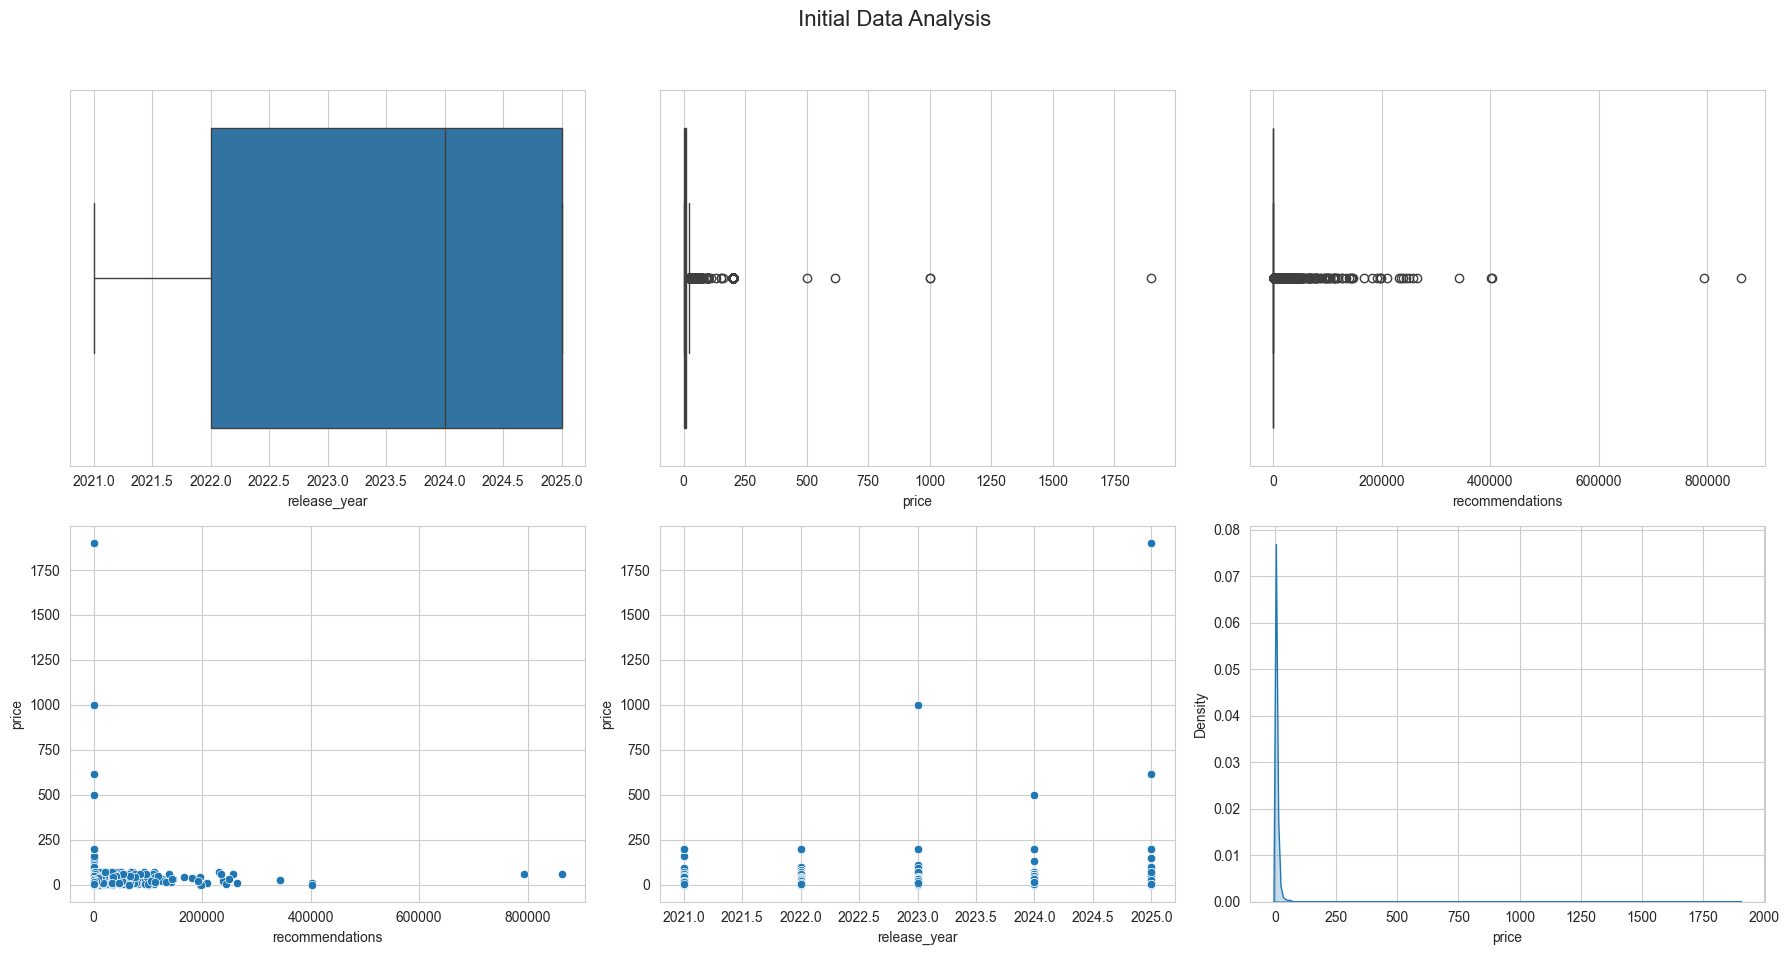

In [102]:
# Generate visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Initial Data Analysis', fontsize=16)
 
sns.boxplot(x=data['release_year'], ax=axes[0, 0])
sns.boxplot(x=data['price'], ax=axes[0, 1])
sns.boxplot(x=data['recommendations'], ax=axes[0, 2])
 
sns.scatterplot(data=data, x='recommendations', y='price', ax=axes[1, 0])
sns.scatterplot(data=data, x='release_year', y='price', ax=axes[1, 1])
 
sns.kdeplot(data=data, x='price', fill=True, ax=axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Advanced Exploratory Data Analysis

In [103]:
data_test = data.copy()

Correlation matrix: 
                    appid  release_year     price  recommendations
appid            1.000000      0.822193 -0.049377        -0.037159
release_year     0.822193      1.000000  0.013420        -0.008288
price           -0.049377      0.013420  1.000000         0.060516
recommendations -0.037159     -0.008288  0.060516         1.000000


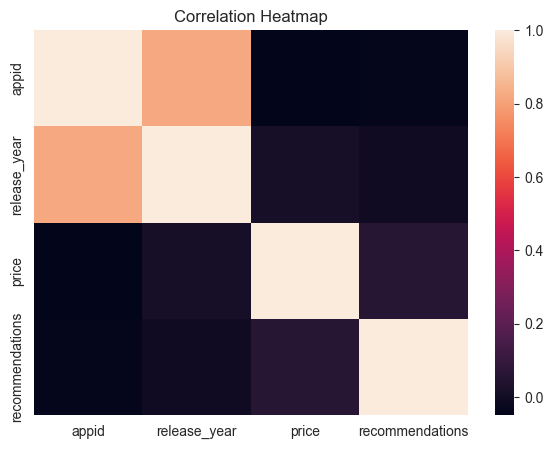

In [104]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
plt.title('Correlation Heatmap')
sns.heatmap(data.corr(numeric_only=True))
print(f'Correlation matrix: \n{data.corr(numeric_only=True)}')

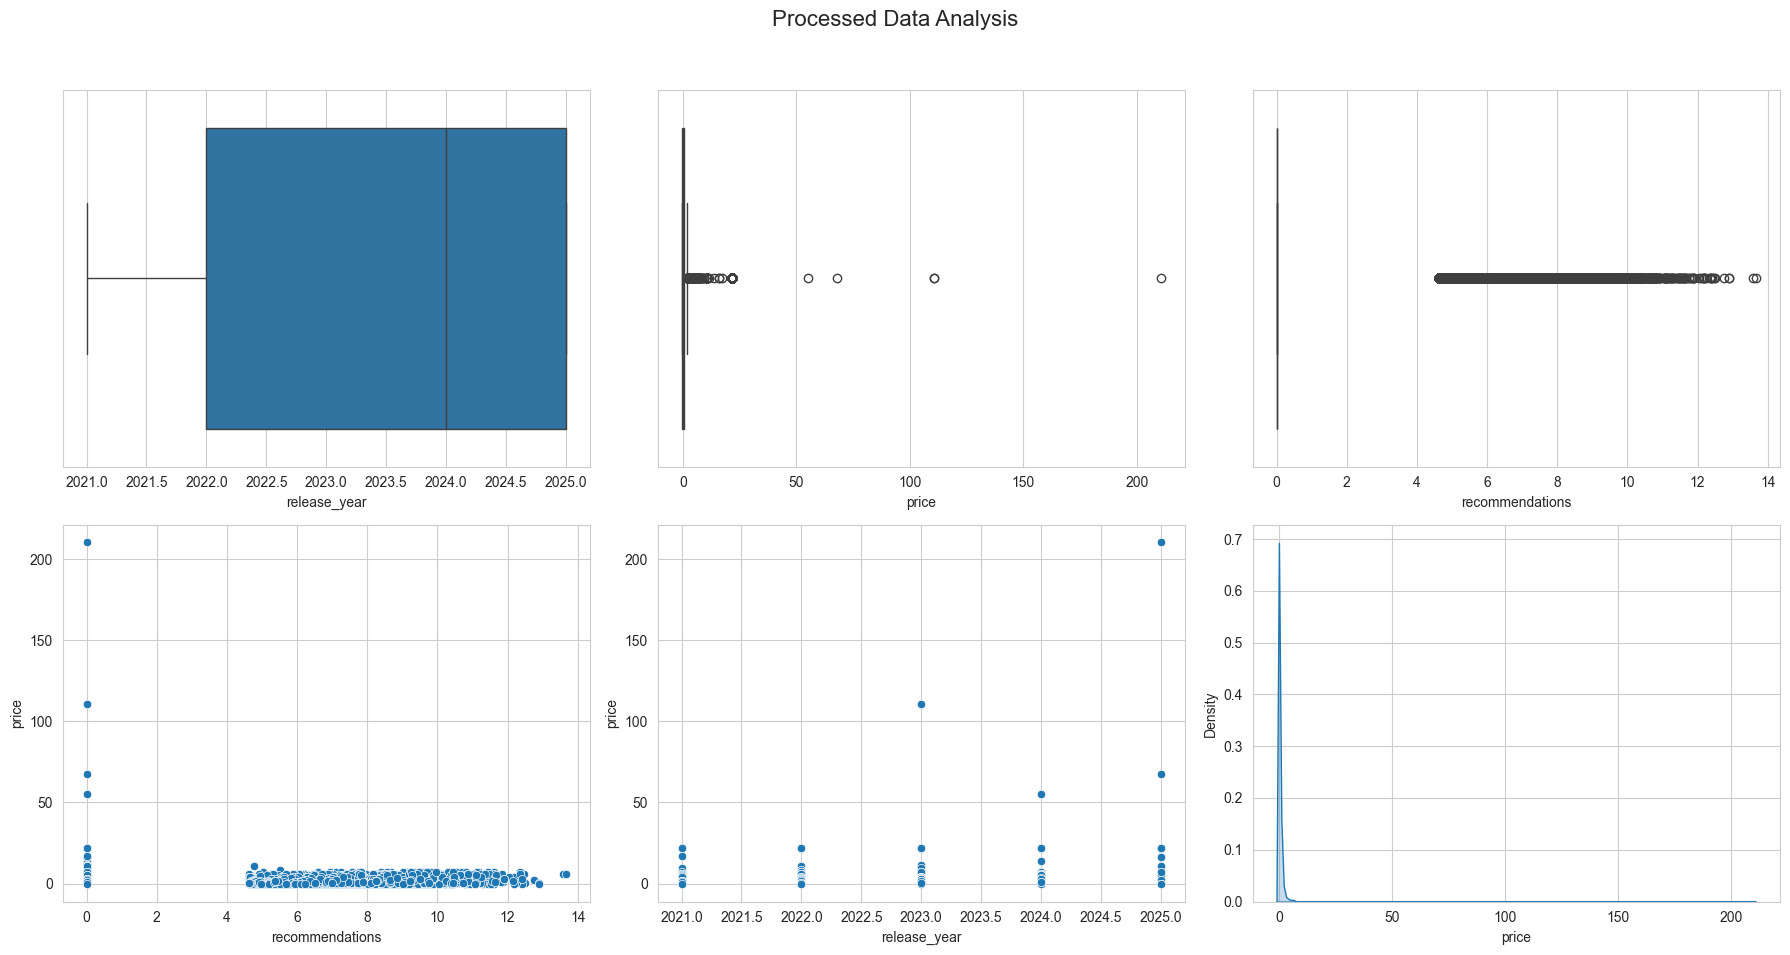

In [105]:
# Test methods to minimize the impact of outliers on recommendations and price. 
scaler = RobustScaler() 
data_test['recommendations'] = np.log1p(data_test['recommendations']) 
data_test[['price', 'recommendations']] = scaler.fit_transform(data_test[['price', 'recommendations']])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Processed Data Analysis', fontsize=16)
 
sns.boxplot(x=data_test['release_year'], ax=axes[0, 0])
sns.boxplot(x=data_test['price'], ax=axes[0, 1])
sns.boxplot(x=data_test['recommendations'], ax=axes[0, 2])
 
sns.scatterplot(data=data_test, x='recommendations', y='price', ax=axes[1, 0])
sns.scatterplot(data=data_test, x='release_year', y='price', ax=axes[1, 1])
 
sns.kdeplot(data=data_test, x='price', fill=True, ax=axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

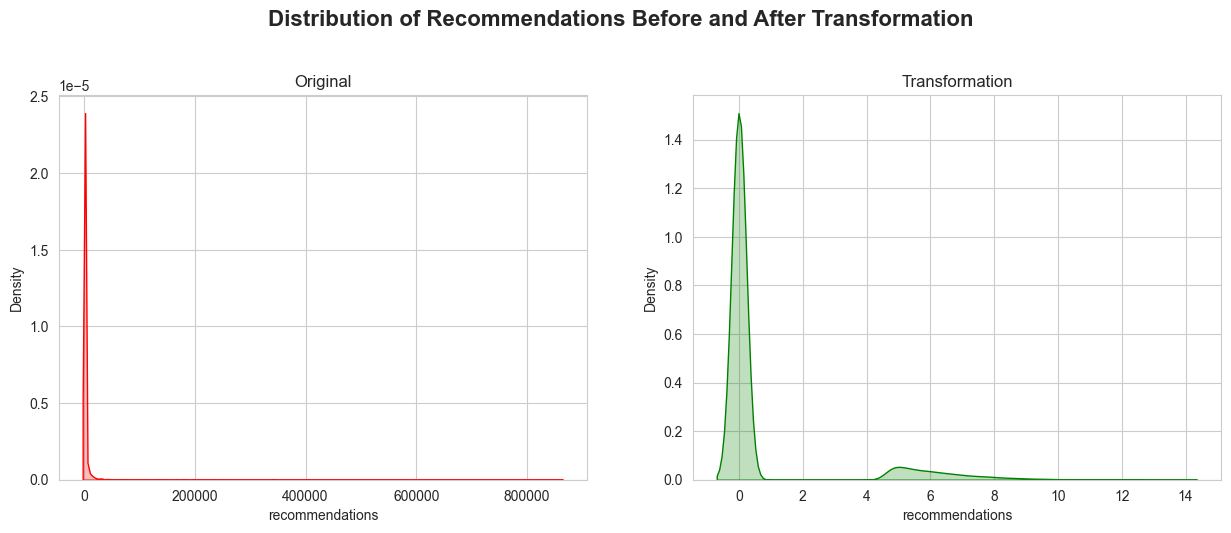

In [106]:
# Visualize the distribution of recommendations before and after the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Distribution of Recommendations Before and After Transformation', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(data['recommendations'], ax=axes[0], fill=True, color="red")
axes[0].set_title("Original")
 
sns.kdeplot(data_test['recommendations'], ax=axes[1], fill=True, color="green")
axes[1].set_title("Transformation")

plt.show()

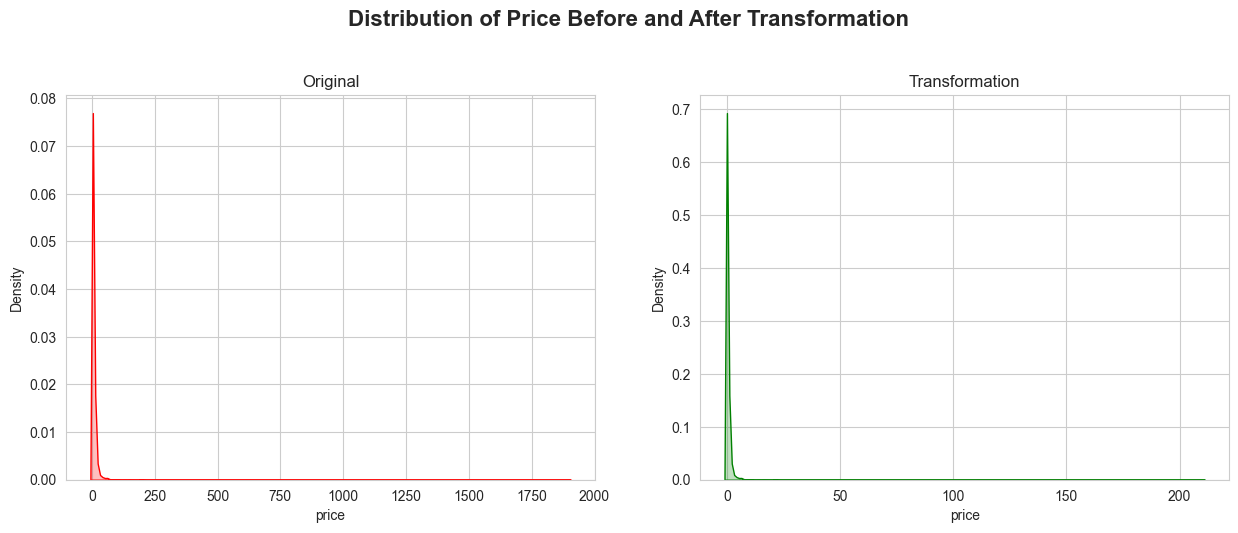

In [107]:
# Visualize the distribution of price before and after the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Distribution of Price Before and After Transformation', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(data['price'], ax=axes[0], fill=True, color="red")
axes[0].set_title("Original")
 
sns.kdeplot(data_test['price'], ax=axes[1], fill=True, color="green")
axes[1].set_title("Transformation")

plt.show()

<Axes: xlabel='release_time', ylabel='recommendations'>

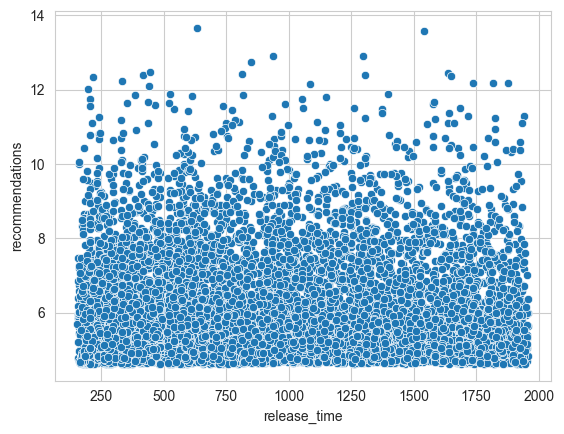

In [108]:
# Relation between release time and popularity (recommendations) 
today = datetime.now()
data_test['release_time'] = (today - data_test['release_date']).dt.days 
popular_games = data_test['recommendations'] != 0
sns.scatterplot(data=data_test[popular_games], x='release_time', y='recommendations') 

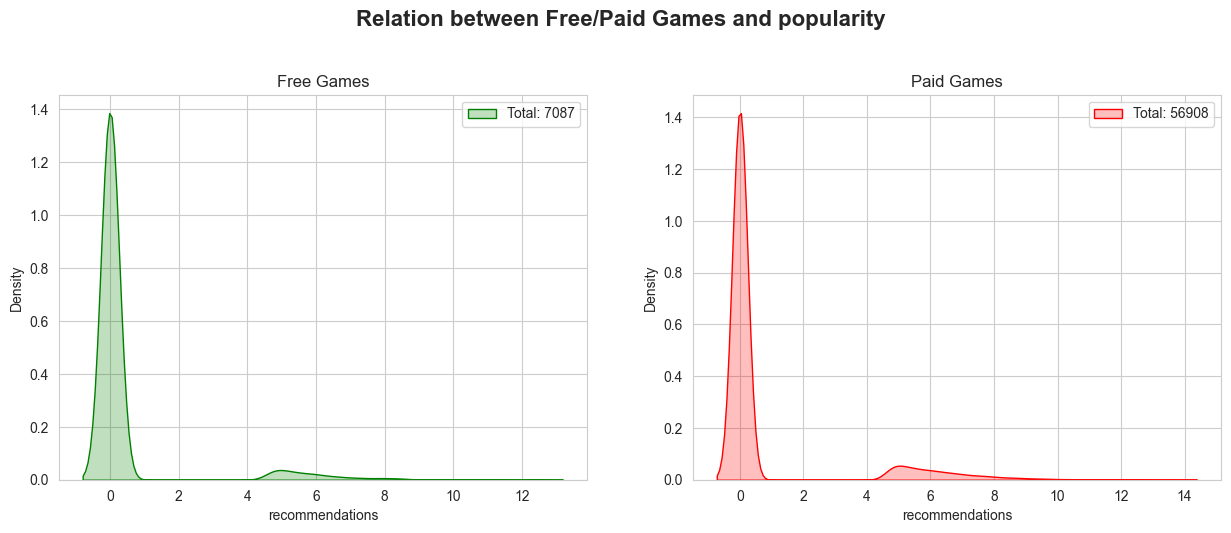

In [109]:
# Relation between Free/Paid Games popularity   
f2p = data_test['price'] == 0 
free_games = data_test[f2p]
paid_games = data_test[~f2p]


fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Relation between Free/Paid Games and popularity', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(free_games['recommendations'], ax=axes[0], fill=True, color="green", label=f"Total: {len(free_games)}")
axes[0].set_title("Free Games")
axes[0].legend()
 
sns.kdeplot(paid_games['recommendations'], ax=axes[1], fill=True, color="red", label=f"Total: {len(paid_games)}")
axes[1].set_title("Paid Games") 
axes[1].legend()

plt.show()

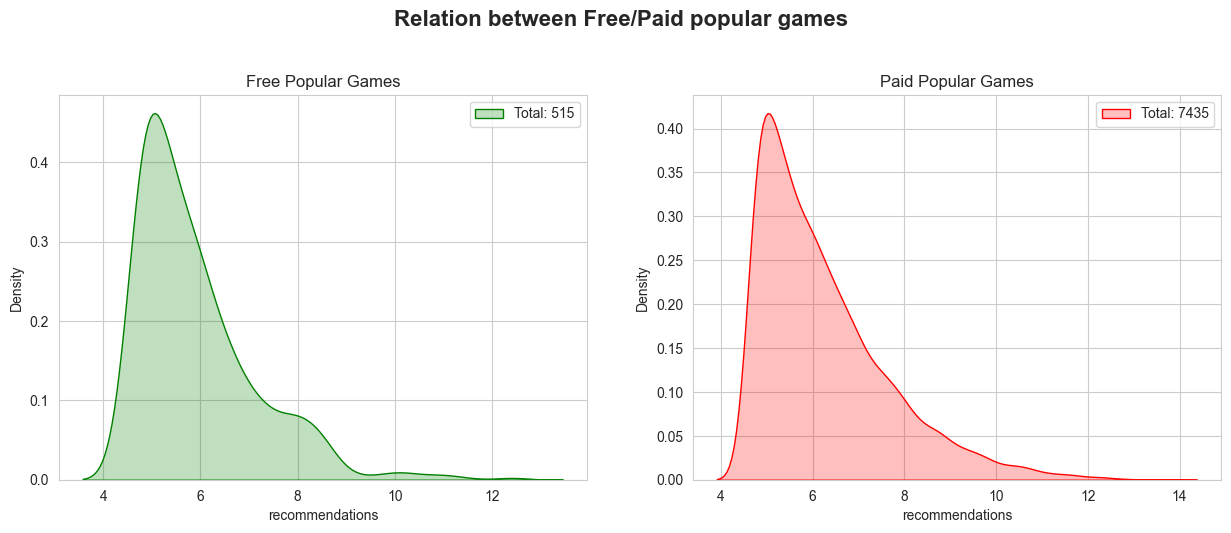

In [110]:
# Relation between Free/Paid popular games   
popular_games = data_test['recommendations'] > 0
free_popular_games = data_test[f2p & popular_games] 
paid_popular_games = data_test[~f2p & popular_games]

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Relation between Free/Paid popular games', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(free_popular_games['recommendations'], ax=axes[0], fill=True, color="green", label=f"Total: {len(free_popular_games)}")
axes[0].set_title("Free Popular Games")
axes[0].legend()
 
sns.kdeplot(paid_popular_games['recommendations'], ax=axes[1], fill=True, color="red", label=f"Total: {len(paid_popular_games)}")
axes[1].set_title("Paid Popular Games") 
axes[1].legend()

plt.show()

In [111]:
# Insights during covid period  
Pandemic = (data['release_date'] >= '2020-03-11') & (data['release_date'] <= '2023-05-05')
No_Pandemic_= ~Pandemic  
print(f'Average price during the pandemic: {data[Pandemic]["price"].mean()}')
print(f'Average price outside the pandemic: {data[No_Pandemic_]["price"].mean()}')
print(f'Average recommendations during the pandemic: {data[Pandemic]["recommendations"].mean()}')
print(f'Average recommendations outside the pandemic: {data[No_Pandemic_]["recommendations"].mean()}')

Average price during the pandemic: 6.936965662871833
Average price outside the pandemic: 7.582524934258841
Average recommendations during the pandemic: 432.45381931692987
Average recommendations outside the pandemic: 337.2640780839118
